#Spotify Data Analysis

In [1]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

Data Loading and Inspection:

In [2]:
#Load dataset
data = pd.read_csv('/content/Spotify_Dataset.csv')

In [3]:
#Working copy of dataset
df=data.copy()

In [4]:
df.head()

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878000,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913000,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339
3,0.1650,1921,0.967,['Frank Parker'],0.275,210000,0.309,0,3ftBPsC5vPBKxYSee08FDH,0.000028,5,0.381,-9.316,1,Danny Boy,3,1921,0.0354,100.109
4,0.2530,1921,0.957,['Phil Regan'],0.418,166693,0.193,0,4d6HGyGT8e121BsdKmw9v6,0.000002,3,0.229,-10.096,1,When Irish Eyes Are Smiling,2,1921,0.0380,101.665


In [5]:
df.tail()

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
170648,0.608,2020,0.08460,"['Anuel AA', 'Daddy Yankee', 'KAROL G', 'Ozuna...",0.786,301714,0.808,0,0KkIkfsLEJbrcIhYsCL7L5,0.000289,7,0.0822,-3.702,1,China,72,2020-05-29,0.0881,105.029
170649,0.734,2020,0.20600,['Ashnikko'],0.717,150654,0.753,0,0OStKKAuXlxA0fMH54Qs6E,0.000000,7,0.1010,-6.020,1,Halloweenie III: Seven Days,68,2020-10-23,0.0605,137.936
170650,0.637,2020,0.10100,['MAMAMOO'],0.634,211280,0.858,0,4BZXVFYCb76Q0Klojq4piV,0.000009,4,0.2580,-2.226,0,AYA,76,2020-11-03,0.0809,91.688
170651,0.195,2020,0.00998,['Eminem'],0.671,337147,0.623,1,5SiZJoLXp3WOl3J4C8IK0d,0.000008,2,0.6430,-7.161,1,Darkness,70,2020-01-17,0.3080,75.055
170652,0.642,2020,0.13200,"['KEVVO', 'J Balvin']",0.856,189507,0.721,1,7HmnJHfs0BkFzX4x8j0hkl,0.004710,7,0.1820,-4.928,1,Billetes Azules (with J Balvin),74,2020-10-16,0.1080,94.991


In [7]:
df.shape

(170653, 19)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  object 
 15  popularity        170653 non-null  int64  
 16  release_date      17

In [9]:
df.describe()

,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo
count,170653.000000,170653.000000,170653.000000,170653.000000,1.706530e+05,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000
mean,0.528587,1976.787241,0.502115,0.537396,2.309483e+05,0.482389,0.084575,0.167010,5.199844,0.205839,-11.467990,0.706902,31.431794,0.098393,116.861590
std,0.263171,25.917853,0.376032,0.176138,1.261184e+05,0.267646,0.278249,0.313475,3.515094,0.174805,5.697943,0.455184,21.826615,0.162740,30.708533
min,0.000000,1921.000000,0.000000,0.000000,5.108000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000
25%,0.317000,1956.000000,0.102000,0.415000,1.698270e+05,0.255000,0.000000,0.000000,2.000000,0.098800,-14.615000,0.000000,11.000000,0.034900,93.421000
50%,0.540000,1977.000000,0.516000,0.548000,2.074670e+05,0.471000,0.000000,0.000216,5.000000,0.136000,-10.580000,1.000000,33.000000,0.045000,114.729000
75%,0.747000,1999.000000,0.893000,0.668000,2.624000e+05,0.703000,0.000000,0.102000,8.000000,0.261000,-7.183000,1.000000,48.000000,0.075600,135.537000
max,1.000000,2020.000000,0.996000,0.988000,5.403500e+06,1.000000,1.000000,1.000000,11.000000,1.000000,3.855000,1.000000,100.000000,0.970000,243.507000


Data Cleaning:

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

,0
valence,0
year,0
acousticness,0
artists,0
danceability,0
duration_ms,0
energy,0
explicit,0
id,0
instrumentalness,0


In [12]:
#Drop column "release_date"

df.drop(columns='release_date',inplace=True)

In [13]:
df.shape

(170653, 18)

In [14]:
df.head()

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878000,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913000,3,0.101,-14.850,1,Gati Bali,5,0.0339,110.339
3,0.1650,1921,0.967,['Frank Parker'],0.275,210000,0.309,0,3ftBPsC5vPBKxYSee08FDH,0.000028,5,0.381,-9.316,1,Danny Boy,3,0.0354,100.109
4,0.2530,1921,0.957,['Phil Regan'],0.418,166693,0.193,0,4d6HGyGT8e121BsdKmw9v6,0.000002,3,0.229,-10.096,1,When Irish Eyes Are Smiling,2,0.0380,101.665


Download cleaned csv file

In [18]:
df.to_csv('Spotify_Data_cleaned.csv', index=False)

In [19]:
from google.colab import files
files.download('Spotify_Data_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#EDA

Univariate Analysis

In [20]:
numeric_features=[feature for feature in df.columns if df[feature].dtype!='O']
categorical_features=[feature for feature in df.columns if df[feature].dtype =='O']

#Print columns

print('We have {} numerical features: {}'.format(len(numeric_features),numeric_features))
print('\nWe have {} categorical features: {}'.format(len(categorical_features),categorical_features))

We have 15 numerical features: ['valence', 'year', 'acousticness', 'danceability', 'duration_ms', 'energy', 'explicit', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'popularity', 'speechiness', 'tempo']

We have 3 categorical features: ['artists', 'id', 'name']


In [21]:
#Proportion of count data on categorical columns

for col in categorical_features:
  print(df[col].value_counts(normalize=True)*100)
  print('-----------------------')

artists
['Эрнест Хемингуэй']                     0.709627
['Эрих Мария Ремарк']                    0.625831
['Francisco Canaro']                     0.551997
['Frank Sinatra']                        0.369170
['Ignacio Corsini']                      0.367998
                                           ...   
['Zara Larsson', 'Sabrina Carpenter']    0.000586
['MO3', 'Kevin Gates']                   0.000586
['Dustin Lynch', 'Lauren Alaina']        0.000586
['PawPaw Rod']                           0.000586
['KHEA', 'Lenny Santos']                 0.000586
Name: proportion, Length: 34088, dtype: float64
-----------------------
id
7HmnJHfs0BkFzX4x8j0hkl    0.000586
4BJqT0PrAfrxzMOxytFOIz    0.000586
7xPhfUan2yNtyFG0cUWkt8    0.000586
1o6I8BglA6ylDMrIELygv1    0.000586
3ftBPsC5vPBKxYSee08FDH    0.000586
                            ...   
0POO8XaUgW5Qjbv9sbDy8W    0.000586
0Nk5f07H3JaEunGrYfbqHM    0.000586
0NFeJgmTAV1kDfzSQNK41Z    0.000586
0MJZ4hh60zwsYleWWxT5yW    0.000586
0LcXzABeA84Egudqp

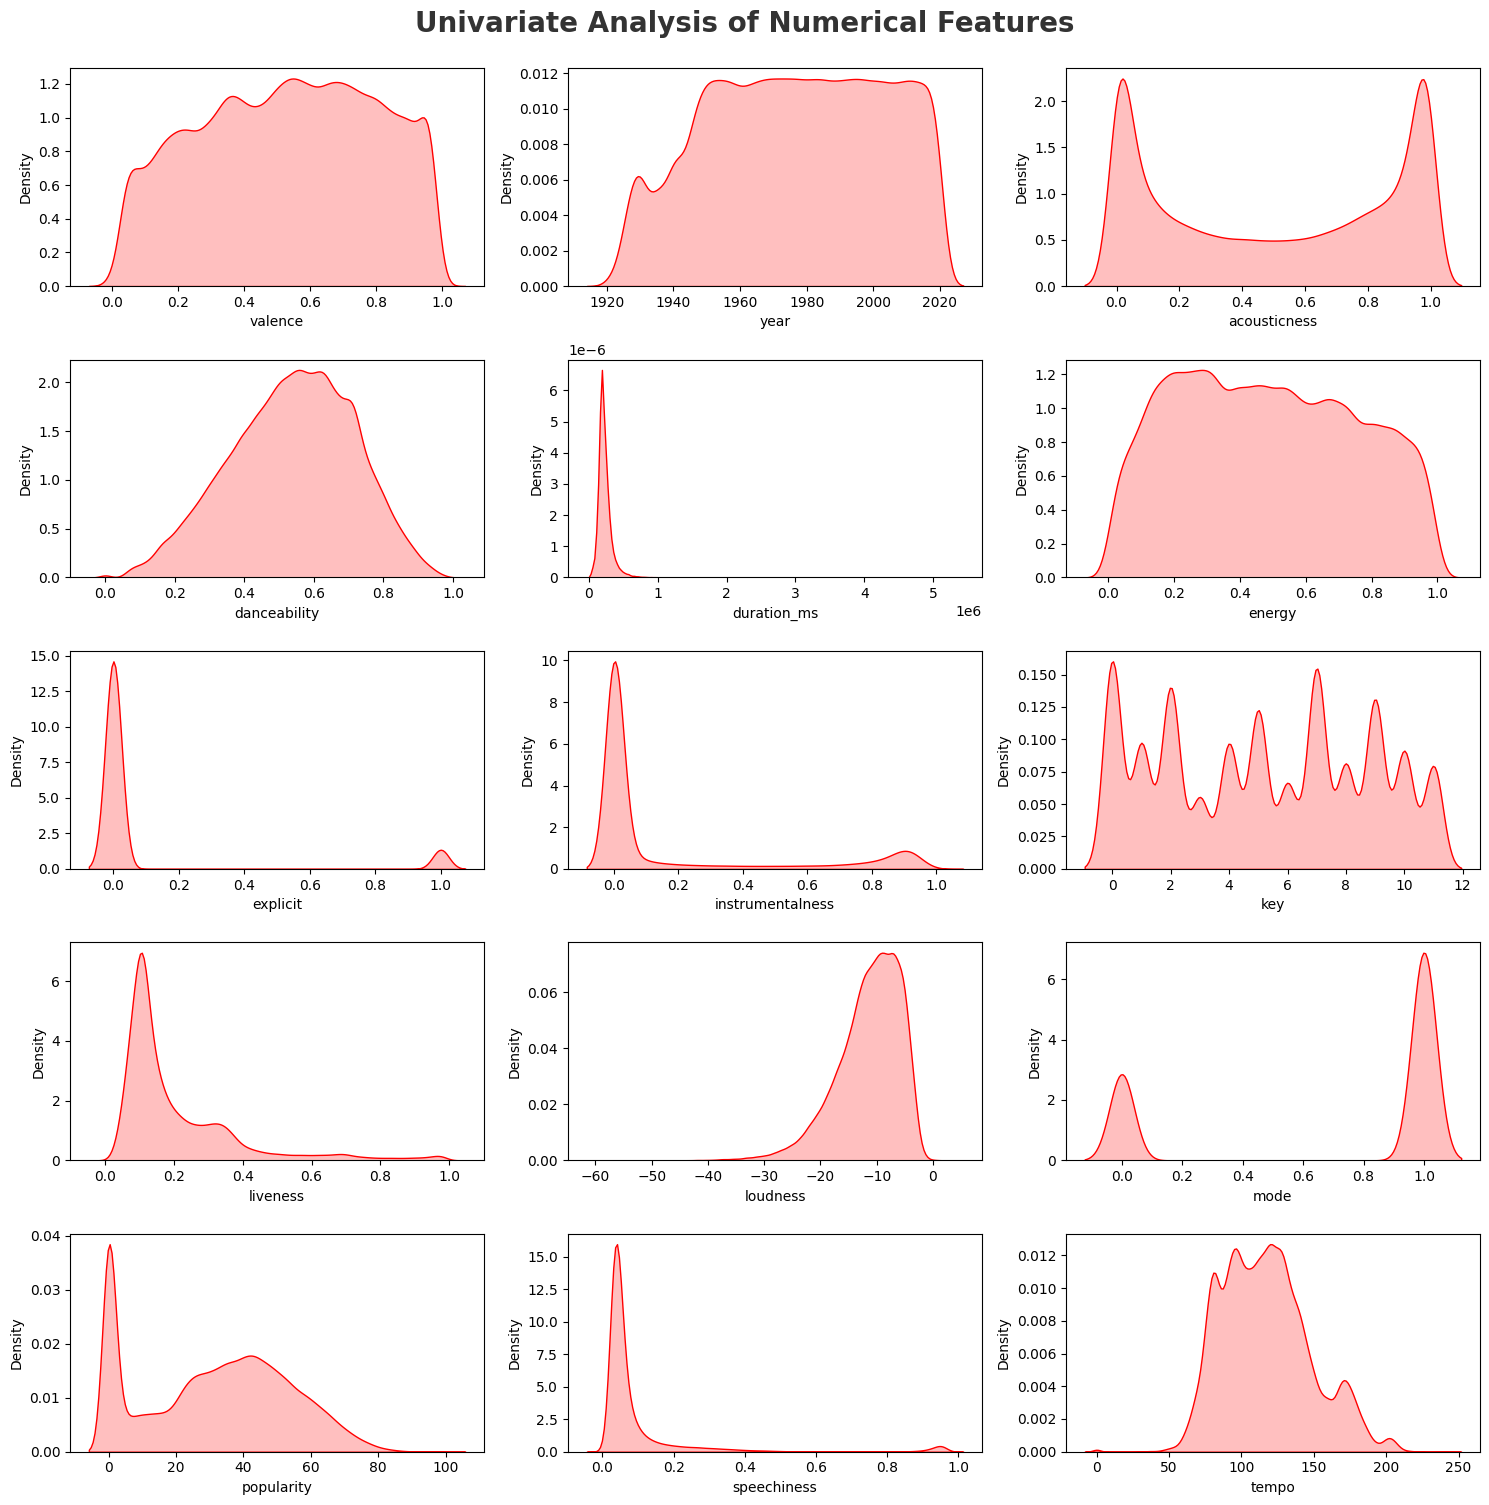

In [23]:
#Proportion of count data on numerical columns

plt.figure(figsize=(15,15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold',alpha=0.8,y=1.)

for i in range(0,len(numeric_features)):
  plt.subplot(5,3,i+1)
  sns.kdeplot(x=df[numeric_features[i]],shade=True,color='r')
  plt.xlabel(numeric_features[i])
  plt.tight_layout()

#Data Analysis

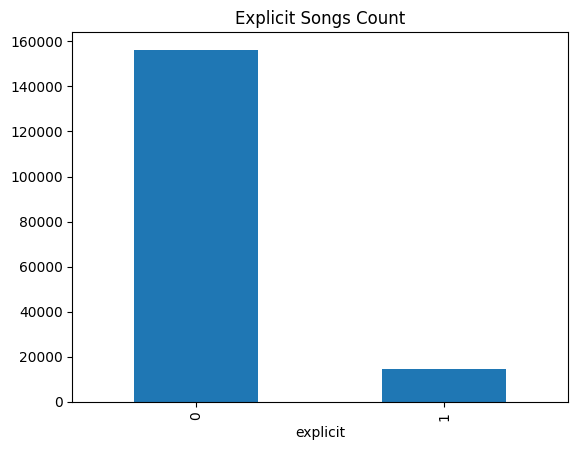

In [28]:
df['explicit'].value_counts().plot(kind='bar')
plt.title("Explicit Songs Count")
plt.show()

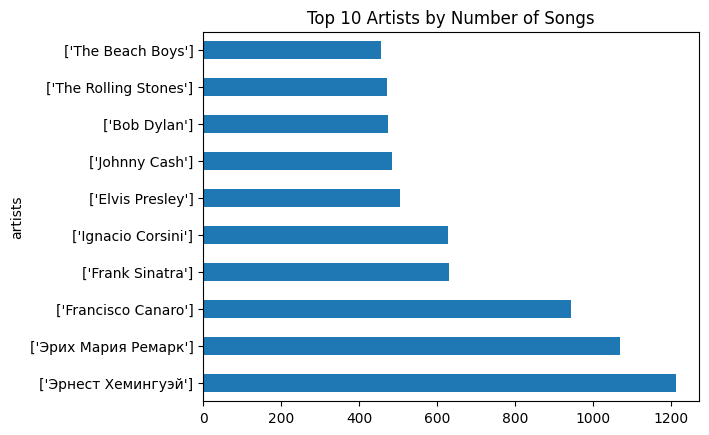

In [29]:
df['artists'].value_counts().head(10).plot(kind='barh')
plt.title("Top 10 Artists by Number of Songs")
plt.show()

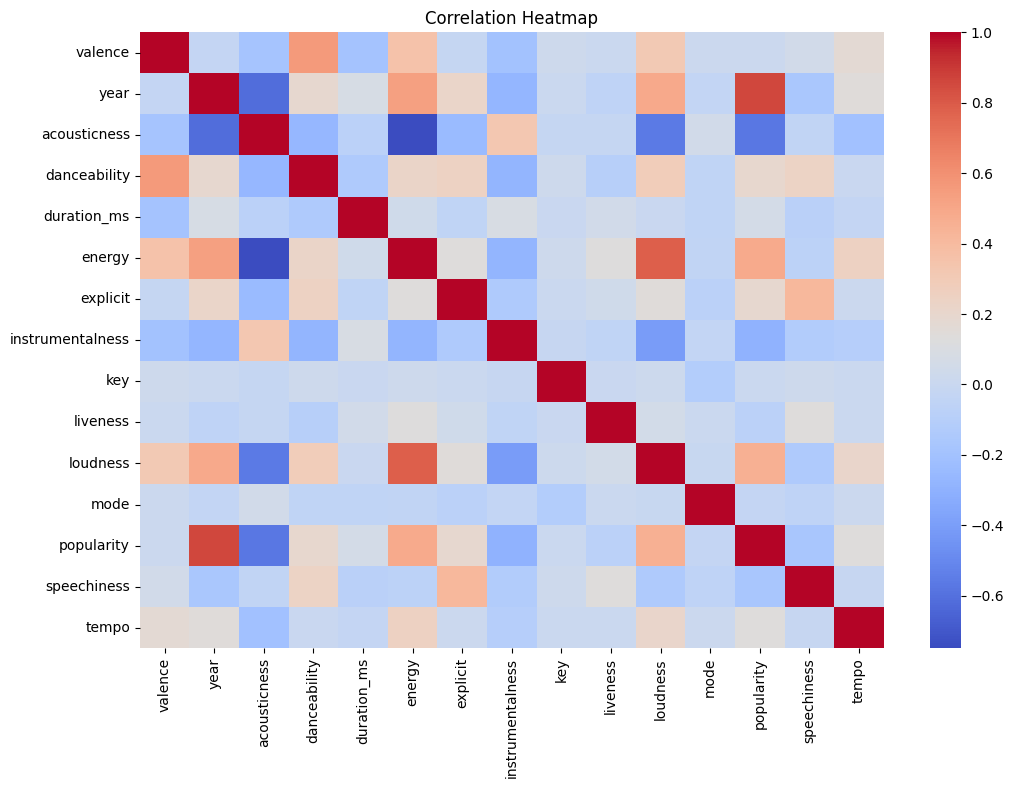

In [31]:
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_features].corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

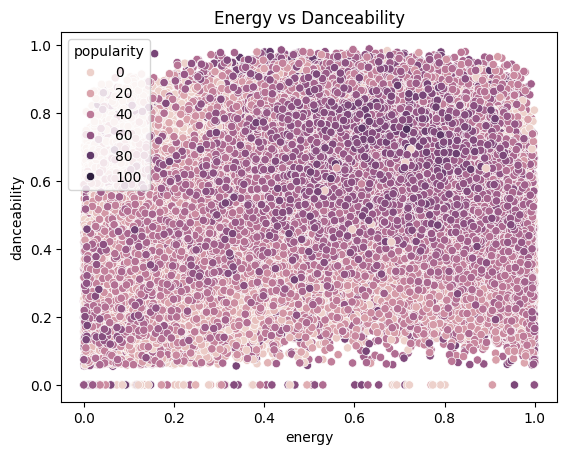

In [32]:
sns.scatterplot(data=df, x='energy', y='danceability', hue='popularity')
plt.title("Energy vs Danceability")
plt.show()

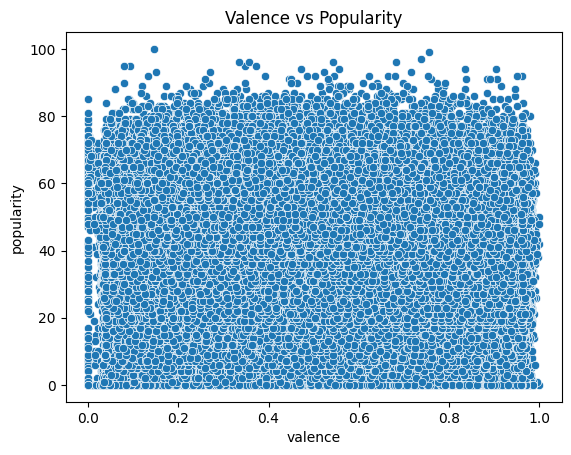

In [33]:
sns.scatterplot(data=df, x='valence', y='popularity')
plt.title("Valence vs Popularity")
plt.show()

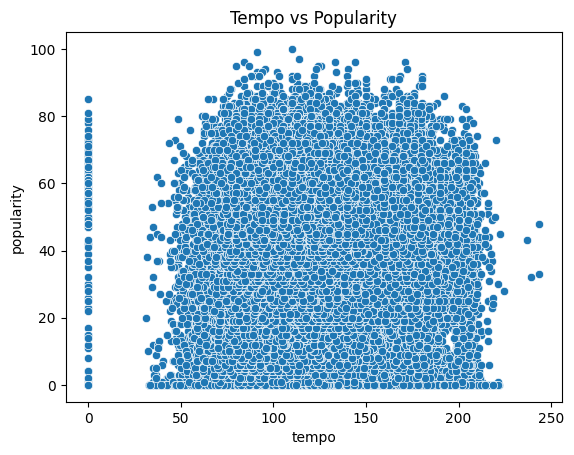

In [34]:
sns.scatterplot(data=df, x='tempo', y='popularity')
plt.title("Tempo vs Popularity")
plt.show()

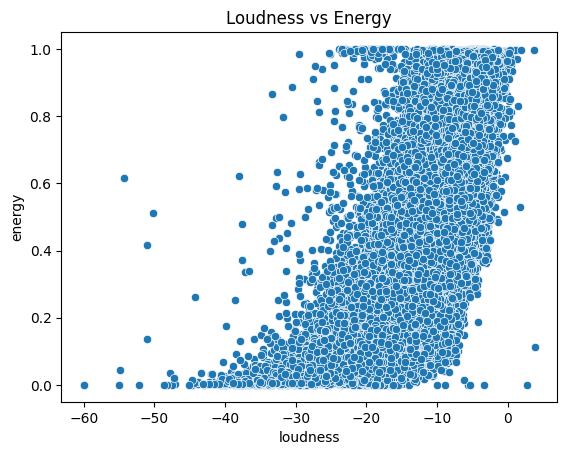

In [35]:
sns.scatterplot(data=df, x='loudness', y='energy')
plt.title("Loudness vs Energy")
plt.show()

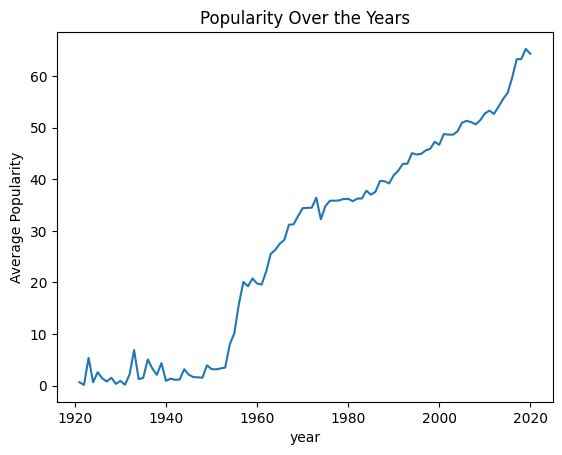

In [36]:
df.groupby('year')['popularity'].mean().plot(kind='line')
plt.title("Popularity Over the Years")
plt.ylabel("Average Popularity")
plt.show()

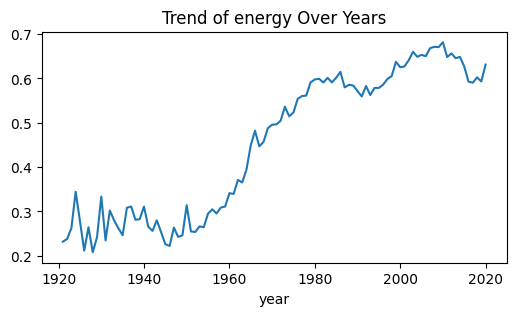

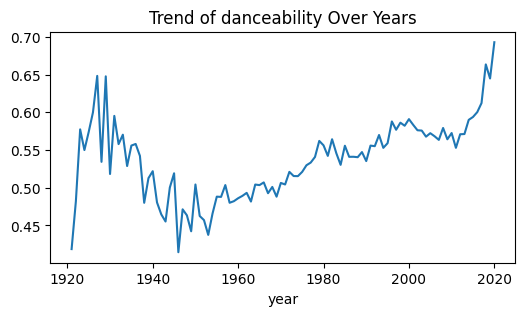

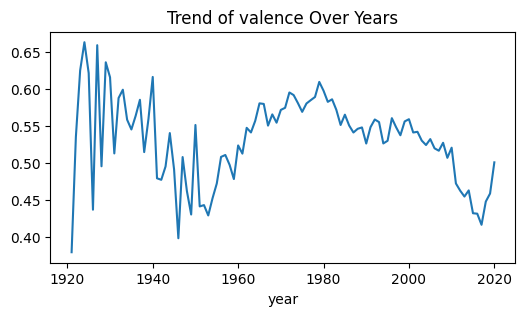

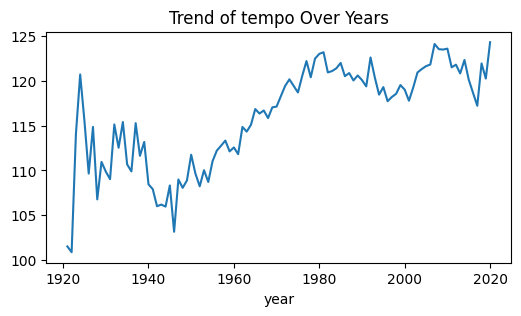

In [37]:
feature_list = ['energy','danceability','valence','tempo']

for feat in feature_list:
    df.groupby('year')[feat].mean().plot(kind='line', figsize=(6,3))
    plt.title(f"Trend of {feat} Over Years")
    plt.show()